In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import PIL
import math
from copy import deepcopy
from collections import deque

# Problema de los flujos máximos
## Motivación
Digamos que se quiere enviar datos a un amigo lo más pronto posible, pero el único canal de comunicación entre lso dos es con una red P2P. En esta red, se puede enviar datos por los caminos que se especifique con ciertos límites en los tamaños de los datos por segundo que se pueden enviar entre pares de nodos en la red.

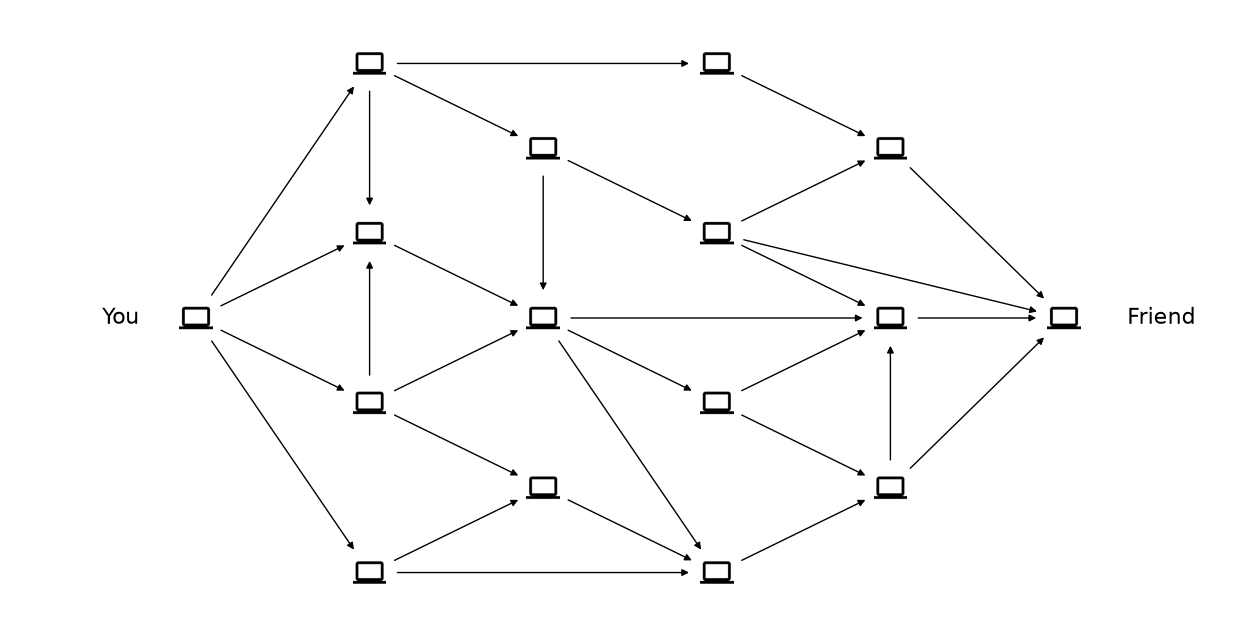

In [3]:
G = nx.read_gml("data/example_graph.gml")

#Extraer información sobre posición de nodos del grafo (para visualizar)
pos = {k: np.asarray(v) for k, v in G.nodes(data="pos")}
label_pos = deepcopy(pos)
label_pos["s"][0] = -1.15
label_pos["t"][0] = 1.20
labels = {"s": "You", "t": "Friend"}

fig, ax = plt.subplots(figsize=(16,8))
nx.draw_networkx_edges(G, pos=pos, ax=ax, min_source_margin=20, min_target_margin=20)
nx.draw_networkx_labels(G, label_pos, labels=labels, ax=ax, font_size=16)
ax.set_xlim([-1.4, 1.4])
ax.axis("off")

#colocar computadores en nodos
tr_figure = ax.transData.transform
tr_axes = fig.transFigure.inverted().transform
icon_size = abs(np.diff(ax.get_xlim())) * 0.015
icon_center = icon_size /2
icon = PIL.Image.open("images/computer_black_144x144.png")
for n in G.nodes:
    xf, yf = tr_figure(pos[n])
    xa, ya = tr_axes((xf,yf))
    a = plt.axes([xa - icon_center, ya - icon_center, icon_size, icon_size])
    a.imshow(icon)
    a.axis("off")
    
# Cómo planear los caminos de los paquetes de datos para enviar lo más rápido posible?
# Nota: Se puede dividir los datos en paquetes

## Formalización
Sea $N = (V,E)$ esta red P2P con $V$ el conjunto de nodos que son computadores y $E$ el conjunto de aristas donde la arista $uv \in E$ si existe una conexión desde el nodo $u$ hasta el nodo $v$ por donde se pueden enviar datos. También hay dos nodos especiales: $s$ eres tú y $t$ es tu amigo. Se llamarán ***fuente*** y ***sumidero***, respectivamente

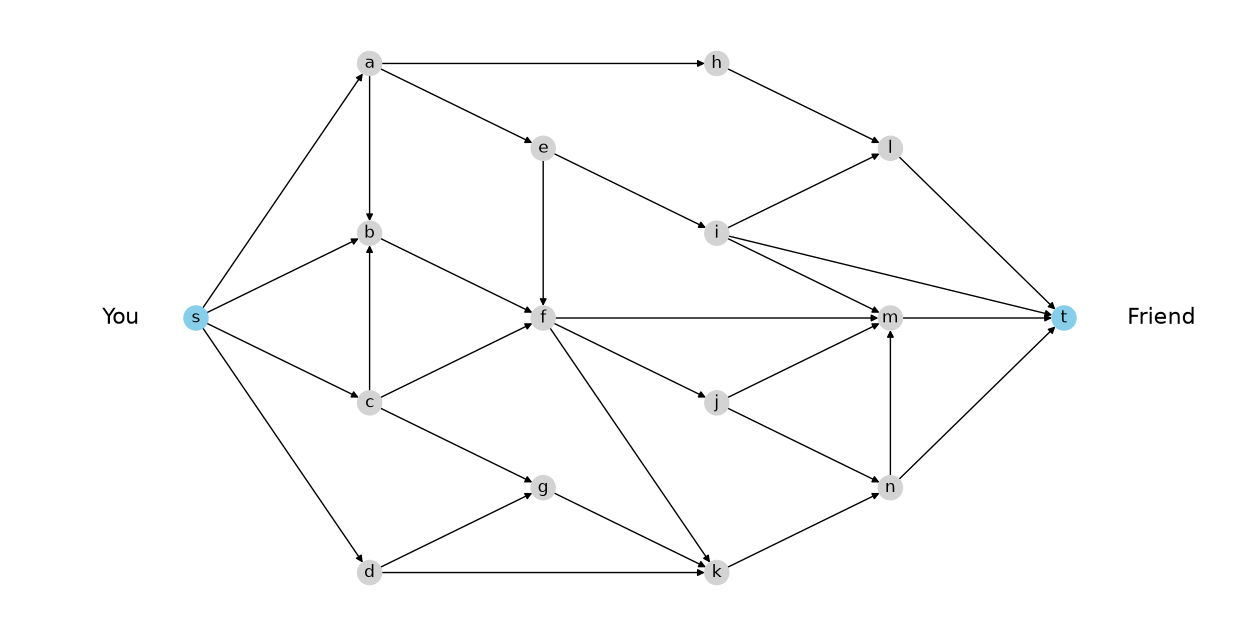

In [6]:
fig, ax = plt.subplots(figsize=(16,8))

#colorear fuente y sumidero
node_colors = ["skyblue" if n in {"s", "t"} else "lightgray" for n in G.nodes]

# dibujar grafo

nx.draw(G, pos, ax=ax, node_color=node_colors, with_labels=True)
nx.draw_networkx_labels(G, label_pos, labels=labels, ax=ax, font_size=16)
ax.set_xlim([-1.4, 1.4]);

Estén los nodos $u$ y $v$ conectados y la cantidad máxima de datos por segundo que se puede enviar entre ellos es $c_{uv}$, llamada la capacidad de la arista $uv$

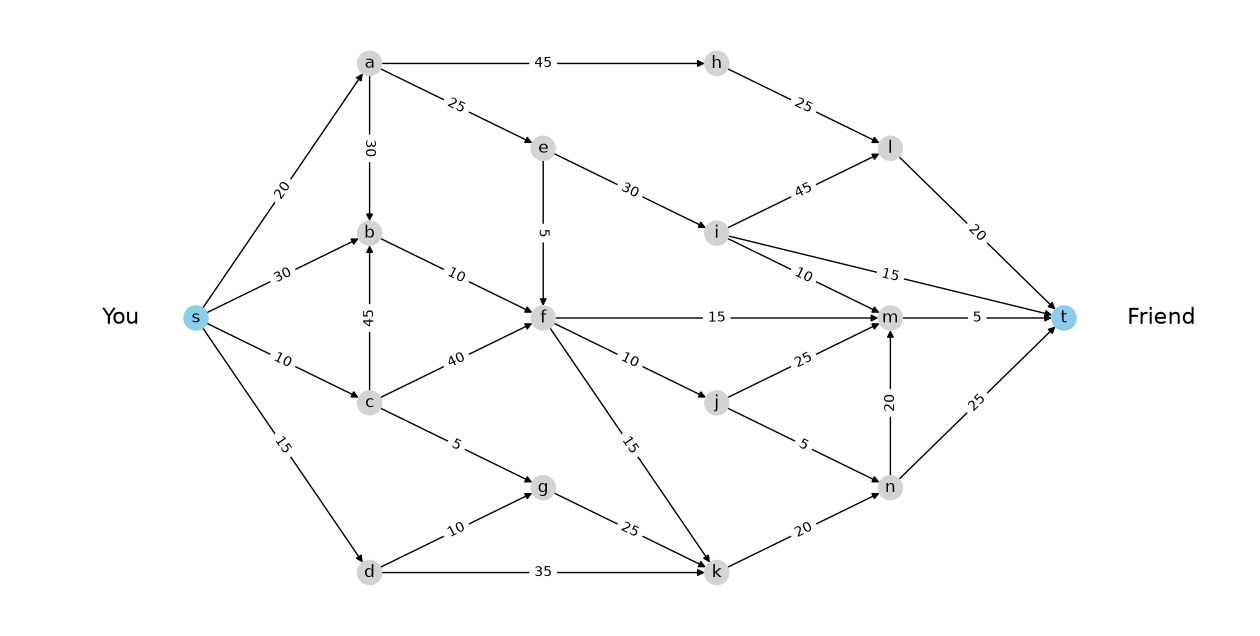

In [7]:
fig, ax = plt.subplots(figsize=(16,8))

# label de capacidades
capacities = {(u,v): c for u, v, c in G.edges(data="capacity")}

# dibujar
nx.draw(G, pos, ax=ax, node_color=node_colors, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=capacities, ax=ax)
nx.draw_networkx_labels(G, label_pos, labels=labels, ax=ax, font_size=16)
ax.set_xlim([-1.4, 1.4]);

Ahora podemos hacer el plan para generar los caminos para mandar los paquetes de datos. Cualquier plan tendrá que tomar cierta capacidad de las aristas, por lo que podemos representarlo con los valores de la capacidad tomados por cada arista en $E$, llámese el plan ***flujo***.

Formalmente, se puede definir ***flujo*** como $f: E \rightarrow \mathbb{R}$. Es decir, un mapeo de las aristas $E$ a n[umeros reales denotando que estamos enviando datos a una tasa $f(uv)$ a través de una arista $uv \in E$.

Nótese que para que este plan sea válido, se deben satisfacer las siguientes restricciones:
   - Restricción de capacidad: La tasa de datos a la que estamos enviando datos desde cualquier nodo no debe exceder su capacidad. Formalmente: $f_{uv} \leq c_{uv}$
    
   - Conservación del flujo: La tasa de datos a la que estamos enviando a un nodo es igual a la tasa con la cual el nodo está enviado a otros nodos, excepto para los nodos $s$ y $t$. Formalmente: $\sum_{u|(u,v)\in E} f_{u,v} = \sum_{w|(v,w)\in E} f_{v,w}, \forall v \in V\notin\{s,t\}$ 

In [9]:
def check_valid_flow(G, flow, source_node, target_node):
    H = nx.DiGraph()
    H.add_edges_from(flow.keys())
    
    for (u,v), f in flow.items():
        capacity = G[u][v]["capacity"]
        H[u][v]["label"] = f"{f}/{capacity}"
        
        # Restricción de capacidad
        if f > G[u][v]["capacity"]:
            H[u][v]["edgecolor"] = "red"
            print(f"Invalid flow: capacity constraint violated for edge ({u!r}, {v!r})")
        # Conservación del flujo
        if v not in {source_node, target_node}:
            incoming_flow = sum(
                flow[(i,v)] if (i, v) in flow else 0 for i in G.predecessors(v)
            )
            outgoing_flow = sum(
                flow[(v,o)] if (v,o) in flow else 0 for o in G.successors(v)
            )
            
            if not math.isclose(incoming_flow, outgoing_flow):
                print(f"Invalid flow: flow conservation violated at node {v}")
                H.nodes[v]["color"] = "red"
    return H

def visualize_flow(flow_graph):
    """Visualizar flujo dvuelto por la funcion anterior"""
    fig, ax = plt.subplots(figsize=(15,9))
    #Dibujar grafo completo
    nx.draw(
        G, pos, ax=ax, node_color=node_colors, edge_color="lightgrey", with_labels=True
    )
    
    flow_nc = [
        "skyblue" if n in {"s", "t"} else flow_graph.nodes[n].get("color", "lightgrey") for n in flow_graph
    ]
    
    flow_ec = [flow_graph[u][v].get("edgecolor", "black") for u, v in flow_graph.edges]
    edge_labels = {(u,v): lbl for u, v, lbl in flow_graph.edges(data="label")}
    nx.draw(flow_graph, pos, ax=ax, node_color=flow_nc, edge_color=flow_ec)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax);

In [11]:
#Flujo valido

example_flow = {
    ("s", "a"): 20,
    ("a", "e"): 15,
    ("e", "i"): 15,
    ("i", "t"): 15,
    ("a", "h"): 5,
    ("h", "l"): 5,
    ("l", "t"): 5,
}

flow_graph = check_valid_flow(G, example_flow, "s", "t")

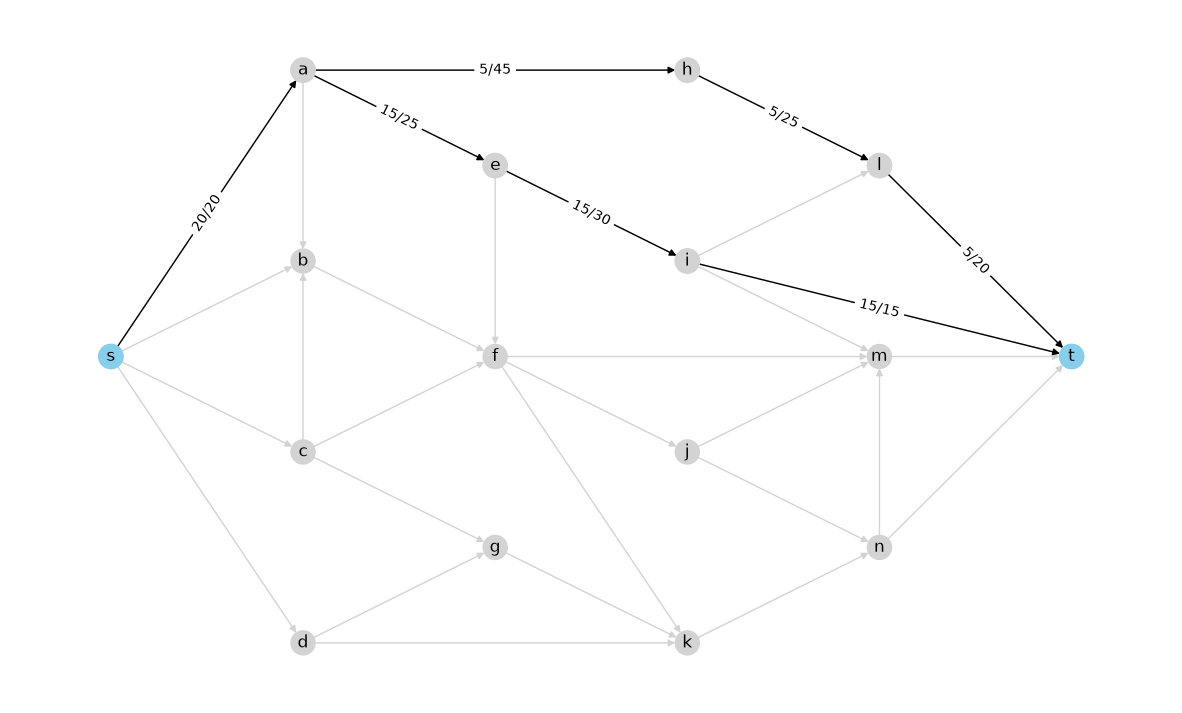

In [12]:
visualize_flow(flow_graph)

In [14]:
#invalido
example_flow = {
    ("s", "a"): 30,
    ("a", "e"): 25,
    ("e", "i"): 15,
    ("i", "t"): 15,
    ("a", "h"): 5,
    ("h", "l"): 5,
    ("l", "t"): 5,
}

flow_graph = check_valid_flow(G, example_flow, "s", "t")

Invalid flow: capacity constraint violated for edge ('s', 'a')
Invalid flow: flow conservation violated at node e


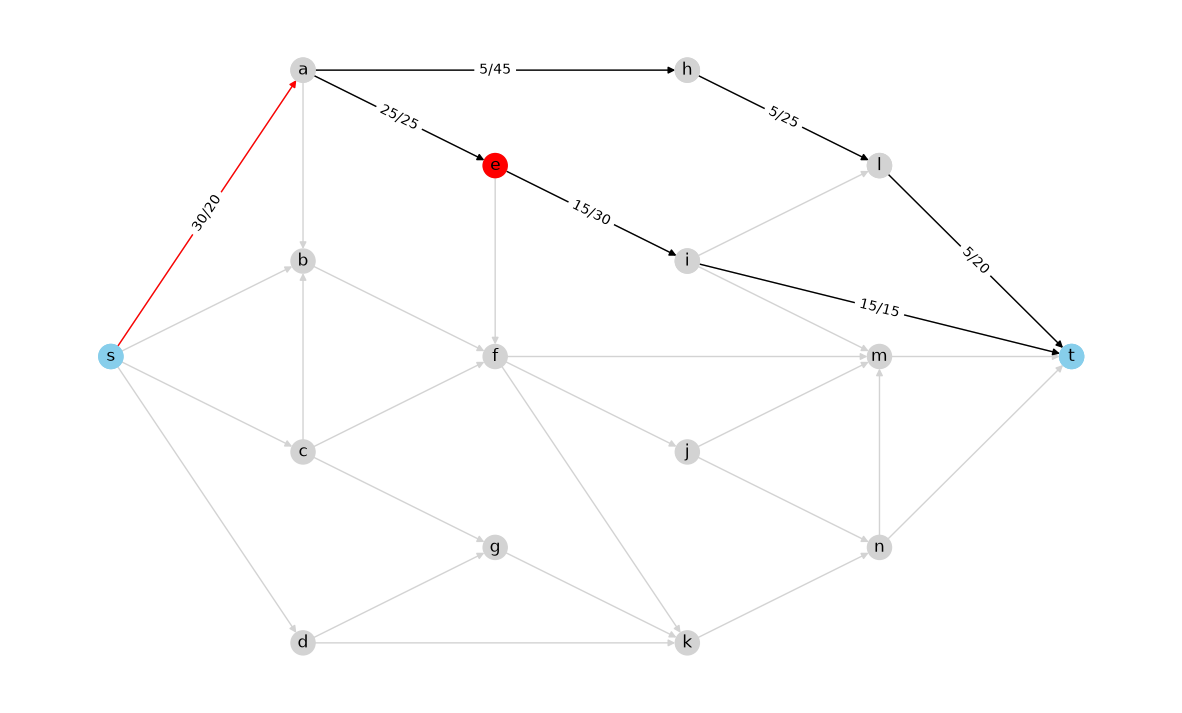

In [15]:
visualize_flow(flow_graph)

Entonces, si usamos este flujo para enviar dtaos, entonces a cuál tasa estaremos enviando los dtos al amigo?

Obsérvese cualquier dato que el nodo sumidero reciba será de sus vecinos, entonces si sumamos las tasas de datos del flujo de esos vecinos hacia el sumidero, tendremos la tasa total a la que el sumidero recibe los dtoas. Formalmente: $|f| = \sum_{u|(u,t) \in E} f_{u,t}$

Como el flujo es conservativo, $|f|$ también sería igual a $\sum_{u|(s,u)\in E} f_{s,u}$.

Recordemos que nuestro objetivo era maximizar la tasa a la cual se transfieren los datos a nuestro amigo, que es lo mismo que maximizar el valor $|f|$. Este esl el ***Problema del Máximo Flujo***.

# Algoritmo de Dinitz
## Definición de términos
**Capacidad residual**: Si enviamos el flujo $f_{uv}$ a través de la arista $uv$ con capacidad $c_{uv}$ entonces definimos la capacidad residual como $g_{uv} = c_{uv} - f_{uv}$ y la red residual como $N'$ que solo considera aristas de $N$ si tienen capacidad residual difernte a cero. 

In [17]:
def residual_graph(G, flow):
    H = G.copy()
    for (u, v), f in flow.items():
        capacity = G[u][v]["capacity"]
        if f > G[u][v]["capacity"]:
            raise ValueError(f"Flow {f} exceeds the capacity of edge {u!r}->{v!r}.")
        H[u][v]["capacity"] -= f
        if H.has_edge(v, u):
            H[v][u]["capacity"] += f
        else:
            H.add_edge(v, u, capacity=f, etype="rev")
    return H


def draw_residual_graph(R, ax=None):
    """Visualize residual graph returned by `residual_graph`."""
    if not ax:
        fig, ax = plt.subplots(figsize=(15, 9))
        ax.axis("off")

    # Draw nodes
    nx.draw_networkx_nodes(R, pos, node_color=node_colors)
    nx.draw_networkx_labels(R, pos)

    # Categorize edges by their capacity and whether they were added by
    # residual_graph
    orig_edges, zero_edges, rev_edges = [], [], []
    for u, v, data in R.edges(data=True):
        if data.get("etype") == "rev":
            rev_edges.append((u, v))
        elif data["capacity"] == 0:
            zero_edges.append((u, v))
        else:
            orig_edges.append((u, v))

    # Draw edges
    nx.draw_networkx_edges(R, pos, edgelist=orig_edges)
    nx.draw_networkx_edges(
        R,
        pos,
        edgelist=rev_edges,
        edge_color="goldenrod",
        connectionstyle="arc3,rad=0.2",
    )
    nx.draw_networkx_edges(
        R, pos, edgelist=zero_edges, style="--", edge_color="lightgrey"
    )

    # Label edges by capacity
    rv = set(rev_edges)
    fwd_caps = {(u, v): c for u, v, c in R.edges(data="capacity") if (u, v) not in rv}
    rev_caps = {(u, v): c for u, v, c in R.edges(data="capacity") if (u, v) in rv}
    nx.draw_networkx_edge_labels(R, pos, edge_labels=fwd_caps, label_pos=0.667)
    nx.draw_networkx_edge_labels(
        R, pos, edge_labels=rev_caps, label_pos=0.667, font_color="goldenrod"
    )

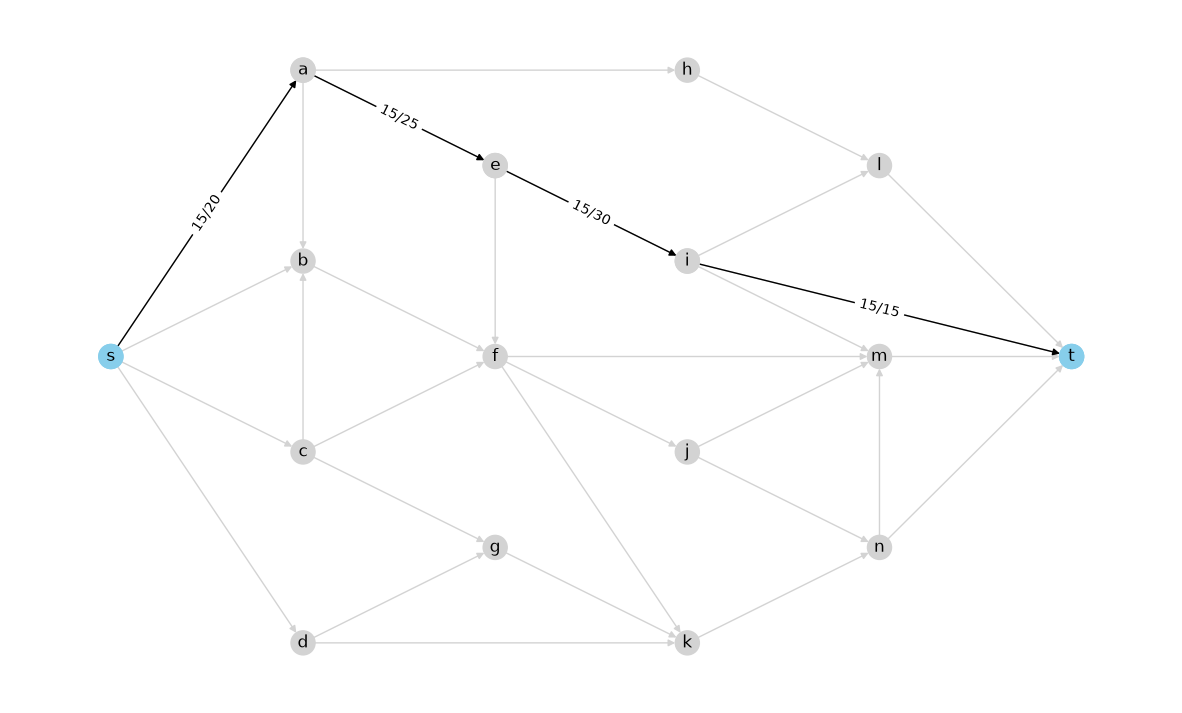

In [18]:
example_flow = {
    ("s", "a"): 15,
    ("a", "e"): 15,
    ("e", "i"): 15,
    ("i", "t"): 15,
}

visualize_flow(check_valid_flow(G, example_flow, "s", "t"))

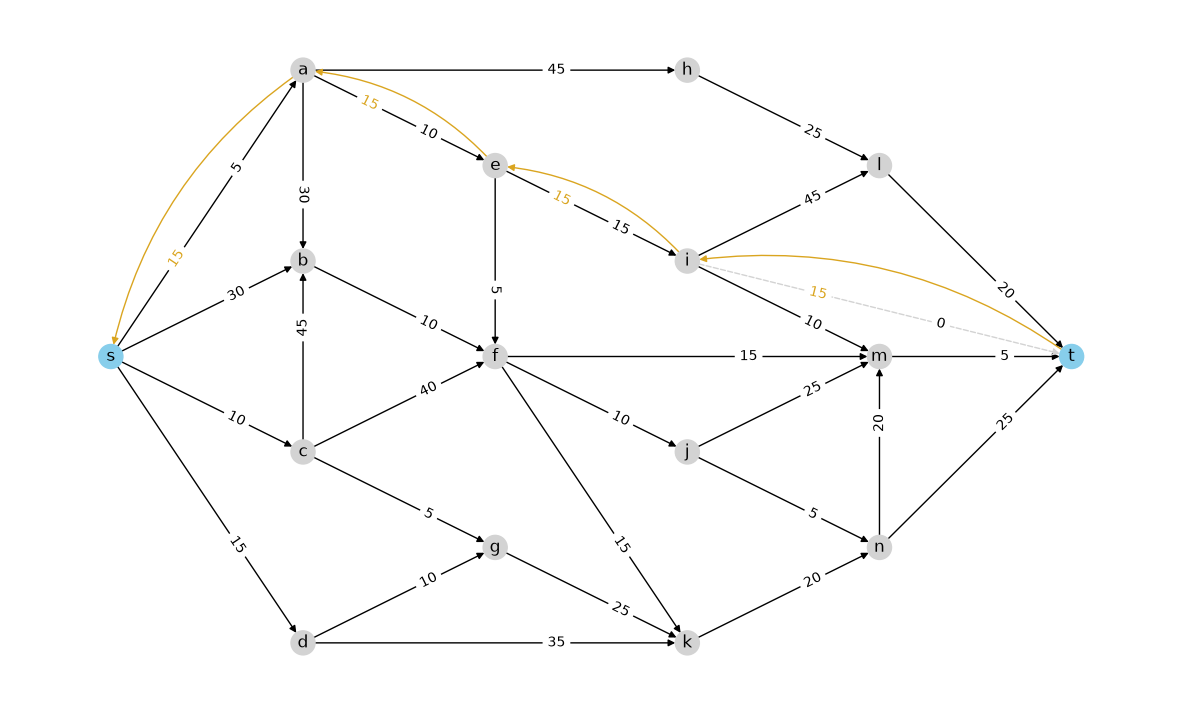

In [20]:
R = residual_graph(G, example_flow)
draw_residual_graph(R)

## Red de nivel
La red de nivel es un subgrafo de la red residual que se obtiene al aplicar BFS desde el nodo $s$ considerando solamente las aristas donde se tiene $c_{uv} - f_{uv} > 0$ en la red residual y se dividen estos nodos en niveles, considerando solamente las aristas que conectan nodos en dos niveles diferentes.


In [22]:
# Mapping between node level and color for visualization
level_colors = {
    1: "aqua",
    2: "lightgreen",
    3: "yellow",
    4: "orange",
    5: "lightpink",
    6: "violet",
}


def level_bfs(R, flow, source_node, target_node):
    """BFS to construct the level network from residual network for given flow."""
    parents, level = {}, {}
    queue = deque([source_node])
    level[source_node] = 0
    while queue:
        if target_node in parents:
            break
        u = queue.popleft()
        for v in R.successors(u):
            if (v not in parents) and (R[u][v]["capacity"] > 0):
                parents[v] = u
                level[v] = level[u] + 1
                queue.append(v)
    return parents, level


def draw_level_network(R, parents, level, background=False):
    fig, ax = plt.subplots(figsize=(15, 9))
    ax.axis("off")

    # Draw nodes
    nodelist = list(level.keys())
    if background:
        level_nc = "lightgrey"
    else:
        level_nc = [level_colors[l] for l in level.values()]
        level_nc[0] = level_nc[-1] = "skyblue"
    nx.draw_networkx_nodes(R, pos, nodelist=nodelist, node_color=level_nc)
    if not background:
        nx.draw_networkx_labels(R, pos)

    # Draw edges
    fwd_edges = [(v, u) for u, v in parents.items() if (v, u) in G.edges]
    labels = {(u, v): R[u][v]["capacity"] for u, v in fwd_edges}
    ec = "lightgrey" if background else "black"
    nx.draw_networkx_edges(R, pos, edgelist=fwd_edges, edge_color=ec)
    if not background:
        nx.draw_networkx_edge_labels(R, pos, edge_labels=labels, label_pos=0.667)

    rev_edges = [(v, u) for u, v in parents.items() if (v, u) not in G.edges]
    labels = {(u, v): R[u][v]["capacity"] for u, v in rev_edges}
    ec = "lightgrey" if background else "goldenrod"
    nx.draw_networkx_edges(
        R, pos, edgelist=rev_edges, connectionstyle="arc3,rad=0.2", edge_color=ec
    )
    if not background:
        nx.draw_networkx_edge_labels(
            R, pos, edge_labels=labels, label_pos=0.667, font_color="goldenrod"
        )

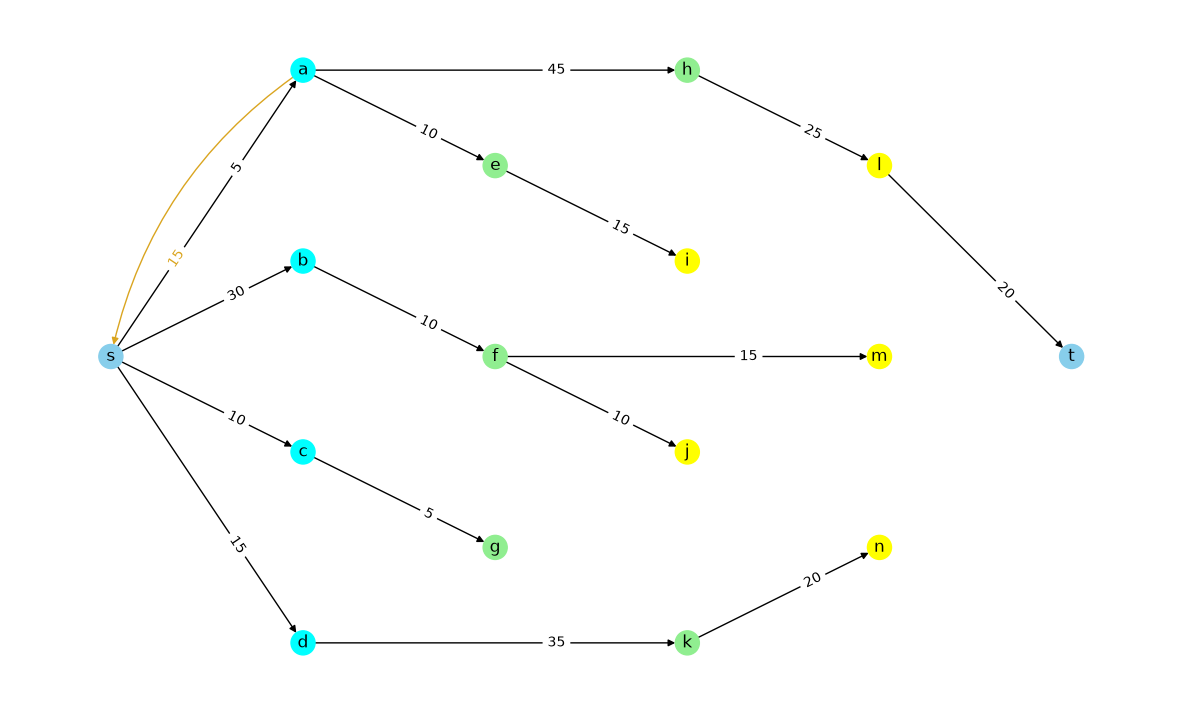

In [23]:
parents, level = level_bfs(R, example_flow, "s", "t")
draw_level_network(R, parents, level)

## Camino aumentado y flujo
Un camino aumentado $P$ es un camino desde el nodo fuente al sumidero donde todas las aristas en el camino tienen capacidad residual positiva tal que $g_{uv} > 0 \forall uv \in P$. Un flujo aumentado $\alpha$ para el camino $P$ es el valor mínimo del flujo residual entre todas las aristas de $P$ tal que $\alpha = \min \{g_{uv}, uv \in P\}$. 

No lo supe ni traducir: And by augmenting the flow along path $P$ we mean that reduce the residual capacities of the edges in path $P$ by $\alpha$ which will leave at least one of the edges on the residual network with zero residual capacity.

Encontramos caminos aumentados aplicando DFS en la red de nivel $L$.

In [24]:
def aug_path_dfs(parents, flow, source_node, target_node):
    """Build a path using DFS starting from the target_node"""
    path = []
    u = target_node
    f = 3 * max(flow.values())  # Initialize flow to large value
    while u != source_node:
        path.append(u)
        v = parents[u]
        f = min(f, R.pred[u][v]["capacity"] - flow.get((u, v), 0))
        u = v
    path.append(source_node)
    # Augment the flow along the path found
    return path, f

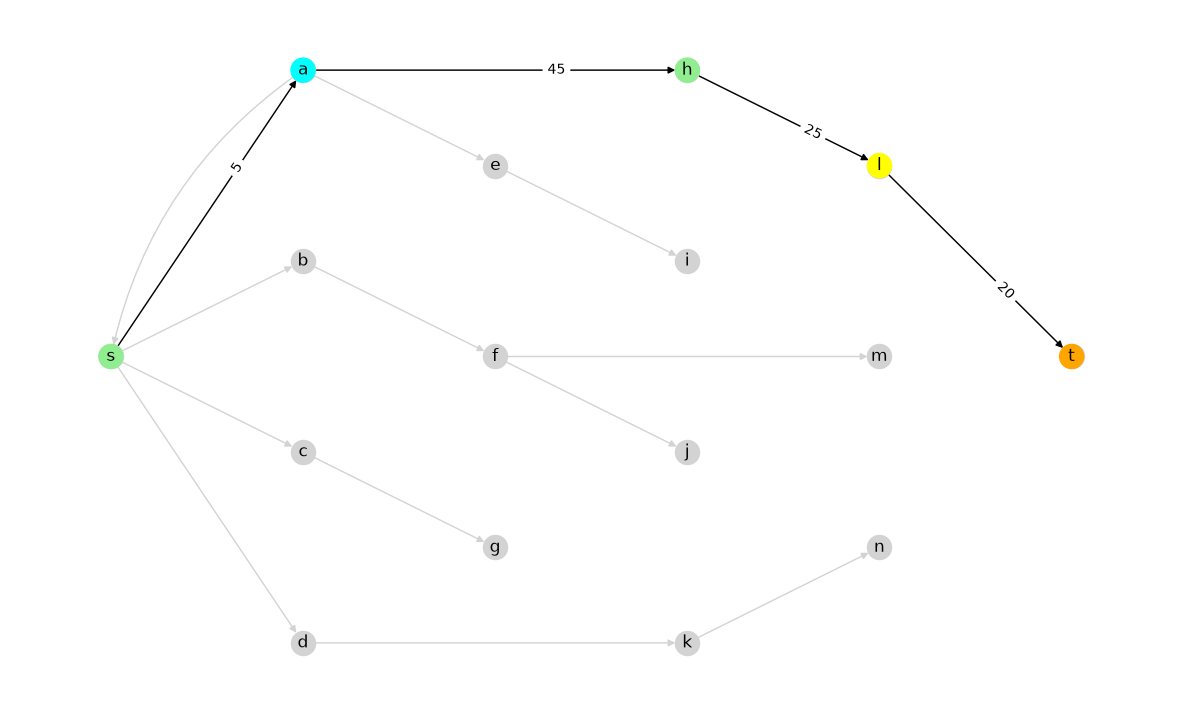

In [25]:
# antes de aumentar
path, min_resid_flow = aug_path_dfs(parents, example_flow, "s", "t")

# Visualize
draw_level_network(R, parents, level, background=True)  # Level graph in the background
nc = [level_colors[level[n]] for n in path]
el = [(v, u) for u, v in nx.utils.pairwise(path)]
nx.draw(R, pos, nodelist=path, edgelist=el, node_color=nc, with_labels=True)
edgelabels = {(u, v): R[u][v]["capacity"] for u, v in el}
nx.draw_networkx_edge_labels(R, pos, edge_labels=edgelabels, label_pos=0.667);

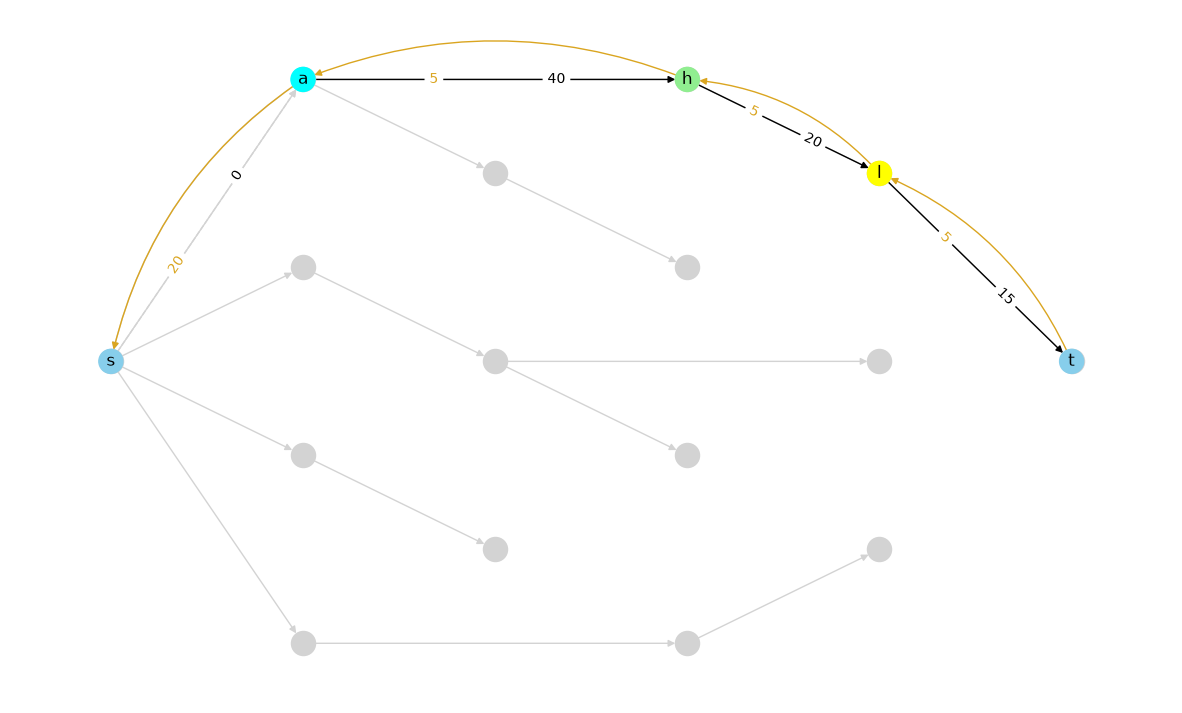

In [26]:
# Después de aumentar
# Apply the minimum flow along the augmenting path
aug_flow = {(v, u): min_resid_flow for u, v in nx.utils.pairwise(path)}

# Visualize the augmented flow along the path
draw_level_network(R, parents, level, background=True)
aug_path = residual_graph(R.subgraph(path), aug_flow)

# Node ordering in the subgraph can be different than `path`
nodes = list(aug_path.nodes)
node_colors = [level_colors[level[n]] for n in nodes]
node_colors[nodes.index("s")] = node_colors[nodes.index("t")] = "skyblue"

draw_residual_graph(aug_path, ax=plt.gca())

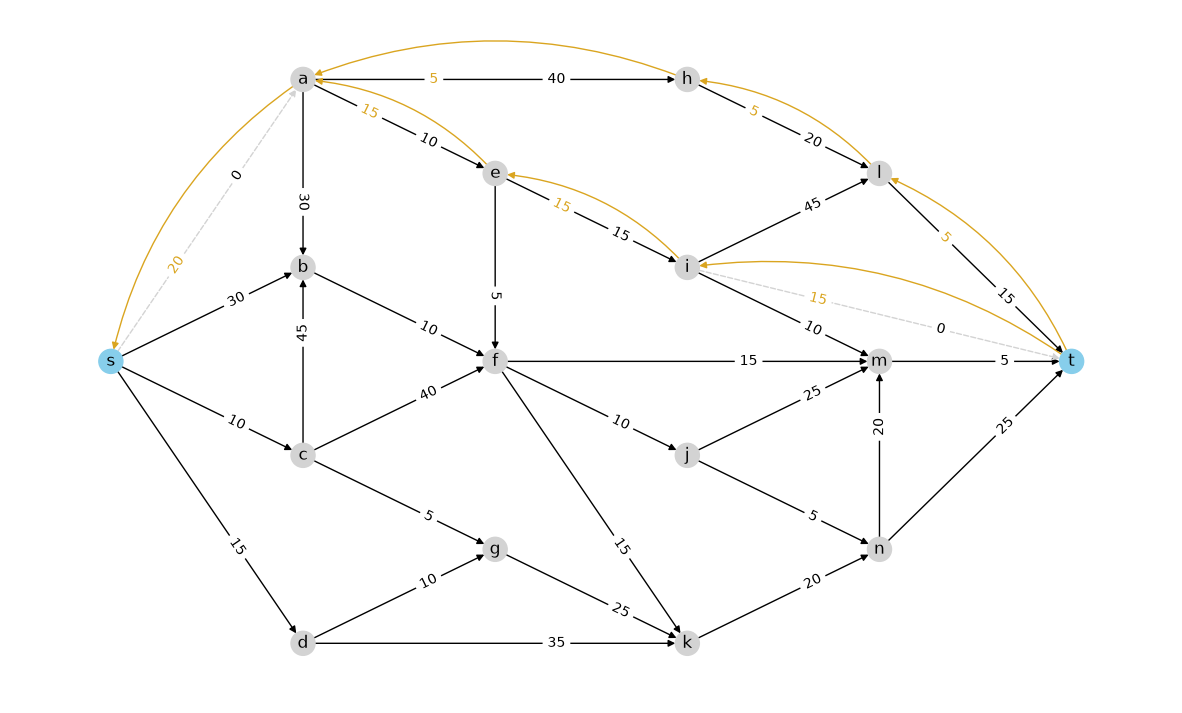

In [27]:
# Resulta en esta red residual
R = residual_graph(R, aug_flow)

# Original color scheme for residual graph
node_colors = ["skyblue" if n in {"s", "t"} else "lightgray" for n in R.nodes]
draw_residual_graph(R)

## Algoritmo
Todo esto se utiliza para ejecutar el algoritmo.
Paso a paso:
1. Inicializar el flujo con valor cero, $f_{uv} = 0$
2. Construir red residual $N'$ a partir de este flujo
3. Encontrar la red de nivel $L$ usando BFS, si $t$ no está en la red de nivel, entonces cortar e imprimir el flujo
4. Encontrar un camino aumentado $P$ en la red de nivel $L$
5. Aumentar el flujo a través de las aristas de camino $P$ que darán una nueva red residual
6. Repetir desde el punto 3 con una nueva red residual $N'$

## Flujo máximo en NetworkX

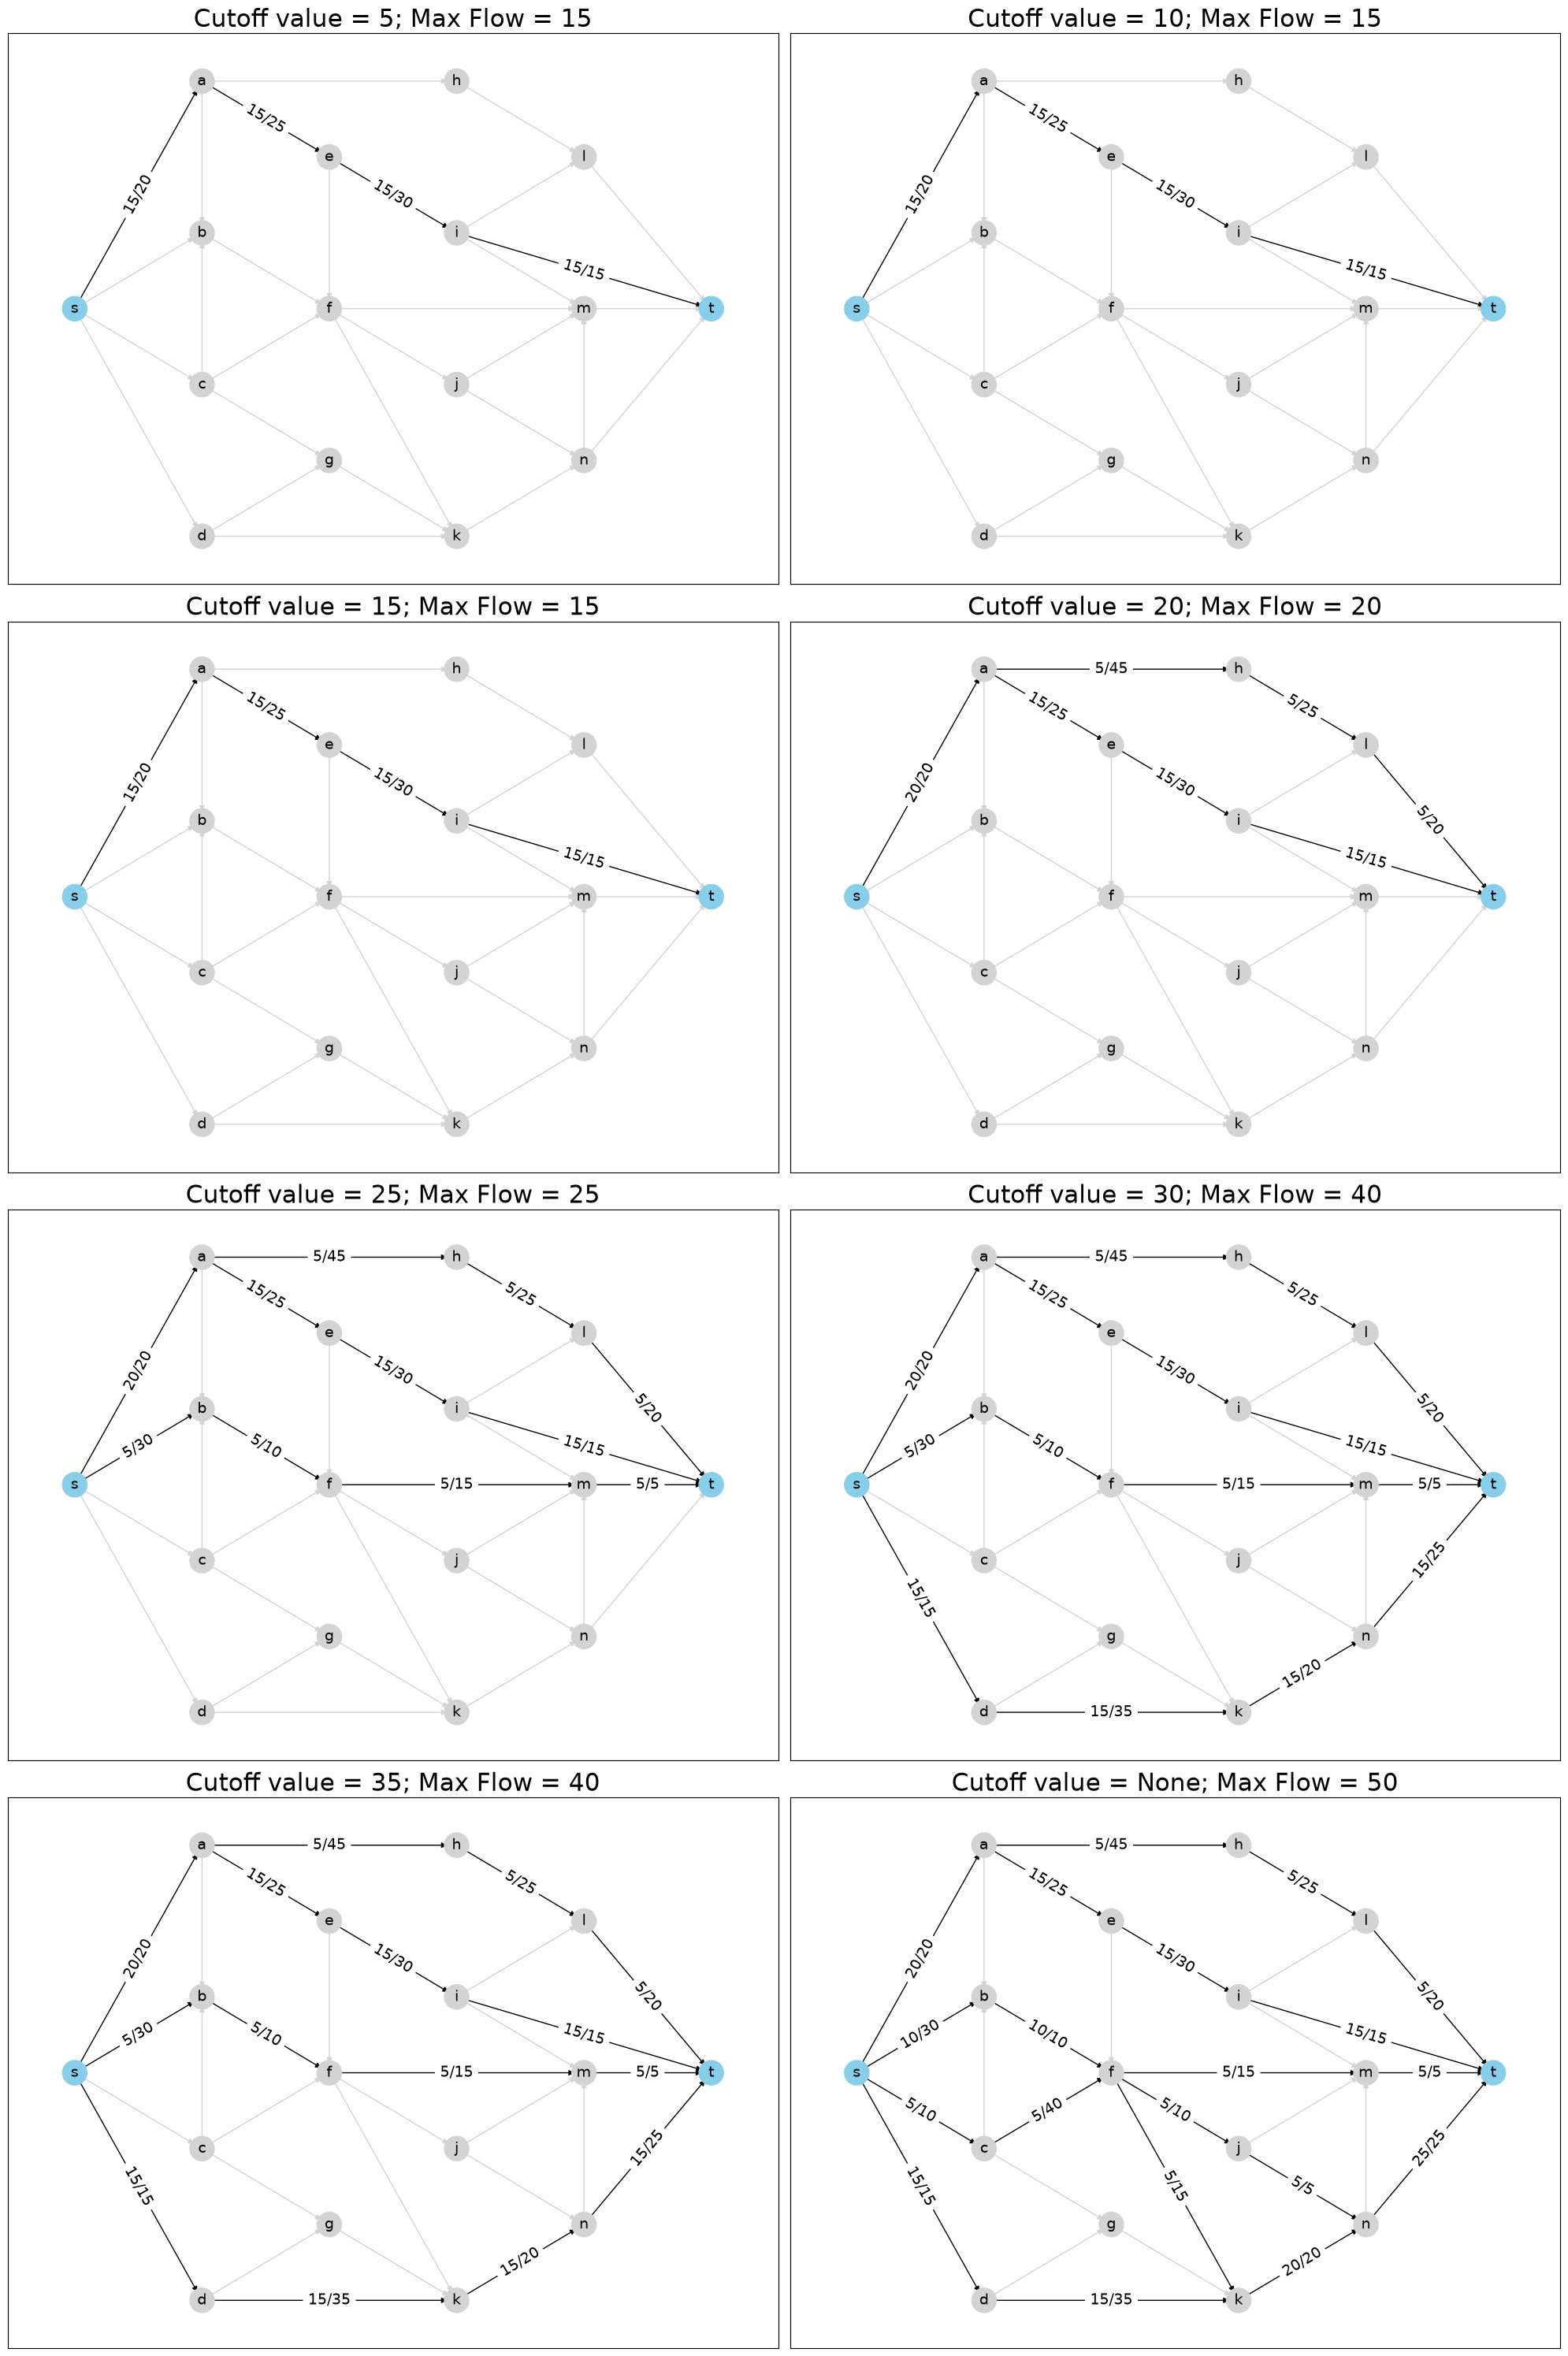

In [28]:
# Maximum flow values to find. Note the final value of `None` which indicates
# the algorithm should run to completion, finding the true maximum flow
cutoff_list = [5, 10, 15, 20, 25, 30, 35, None]

fig, axes = plt.subplots(4, 2, figsize=(20, 30))
node_colors = ["skyblue" if n in {"s", "t"} else "lightgray" for n in G.nodes]

for cutoff, ax in zip(cutoff_list, axes.ravel()):
    # calculating the maximum flow with the cutoff value
    R = nx.flow.dinitz(G, s="s", t="t", capacity="capacity", cutoff=cutoff)

    # coloring and labeling edges depending on if they have non-zero flow value or not
    edge_colors = ["lightgray" if R[u][v]["flow"] == 0 else "black" for u, v in G.edges]
    edge_labels = {
        (u, v): f"{R[u][v]['flow']}/{G[u][v]['capacity']}"
        for u, v in G.edges
        if R[u][v]["flow"] != 0
    }

    # drawing the network
    nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_size=500, node_color=node_colors)
    nx.draw_networkx_labels(G, pos=pos, ax=ax, font_size=14)
    nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color=edge_colors)
    nx.draw_networkx_edge_labels(
        G, pos=pos, ax=ax, edge_labels=edge_labels, font_size=14
    )
    ax.set_title(
        f"Cutoff value = {cutoff}; Max Flow = {R.graph['flow_value']}",
        size=22,
    )

fig.tight_layout()

## Aplicaciones
- Maximum bipartite matching
- Assignment Problem
- Transportation Problem
- ...
Complejidad: $O(n^2m)$. En grafos bipartitos es $O(\sqrt{n}m)$ con $n = |V|$ y $m = |E|$.

### Ejemplo de enviar paquetes de la bodega a personas a través de puntos intermediarios, con limitación en intermediario
Cómo asignamos puntos intermedios a una persona maximizando el número de paquetes enviados en un día?

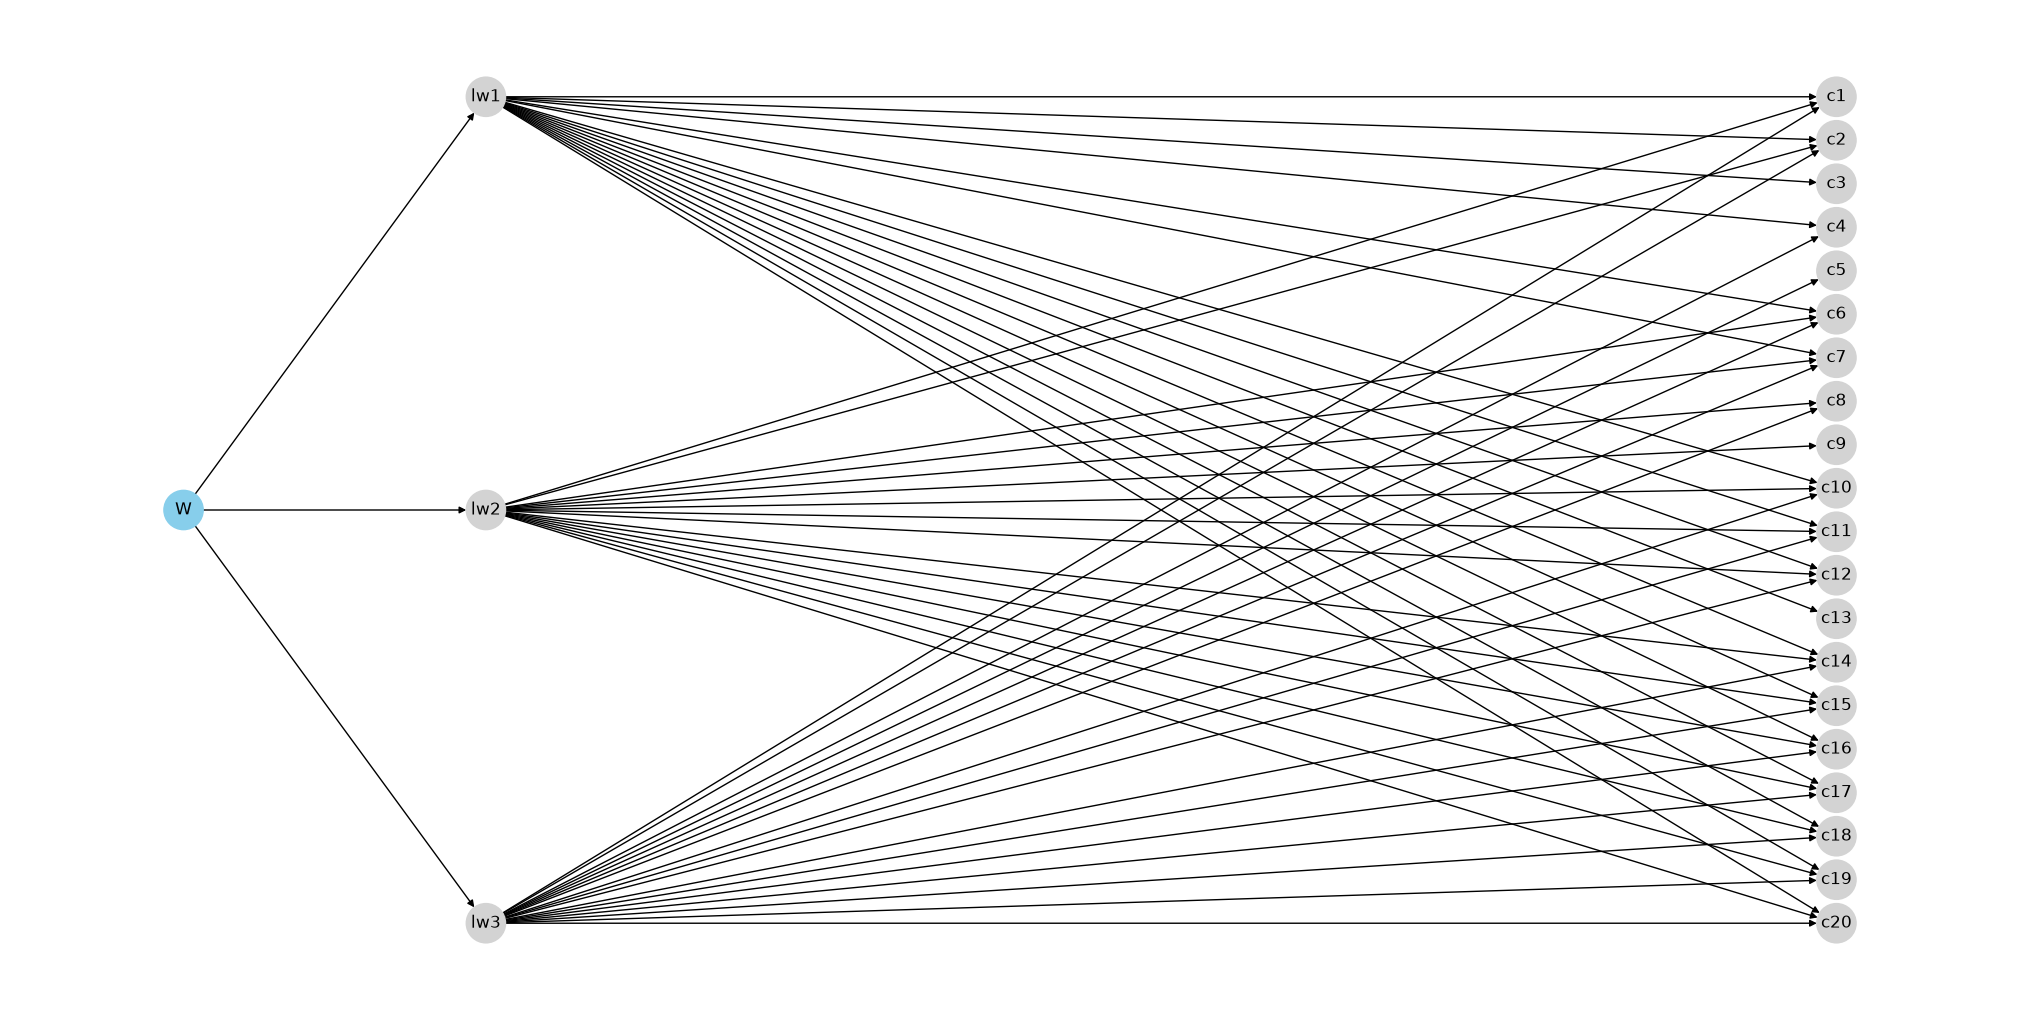

In [29]:
# Load data
B = nx.read_gml("data/shipping_graph.gml")
pos = {k: np.asarray(v) for k, v in B.nodes(data="pos")}

# drawing the loaded graph
node_colors = ["skyblue" if u == "W" else "lightgray" for u in B.nodes]
plt.figure(figsize=(20, 10))
nx.draw(
    B, pos=pos, node_color=node_colors, with_labels=True, arrowsize=10, node_size=800
)

In [30]:
# maximum shipping capacities
{u: B.nodes[u]["maximum_shippings"] for u in ["lw1", "lw2", "lw3"]}

{'lw1': 8, 'lw2': 5, 'lw3': 6}

Añadimos un pseudo nodo $T$ denotando el último nodo sumidero y añadimos aristas desde $ci \rightarrow T, i \in \{1,2,\ldots, 20\}$.
Nótese que enviar más del máximo númeor de paquetes que cualquier $lwi, i \in \{1,2,3\}$ puede enviar en un día es una pérdida de tiempo. Entonces podemos transferir ese máximo número de capacidad a la máxima capacidad de las aristas $W \rightarrow lwi, i \in \{1,2,3\}$ y para las otras aristas, podemos asignar su capacidad como 1 y podemos hacer solo un envío por persona.

In [31]:
# adding node T and edges to T from c1,c2,...c20
B.add_node("T")
pos["T"] = np.array([0.97, 0.0])
B.add_edges_from((f"c{i}", "T") for i in range(1, 21))

# adding capacities from W to lw1, lw2, lw3
for u in ["lw1", "lw2", "lw3"]:
    B["W"][u]["capacity"] = B.nodes[u]["maximum_shippings"]

# adding capacities as 1 for all other edges except edges from W
for u, v in B.edges:
    if u != "W":
        B[u][v]["capacity"] = 1

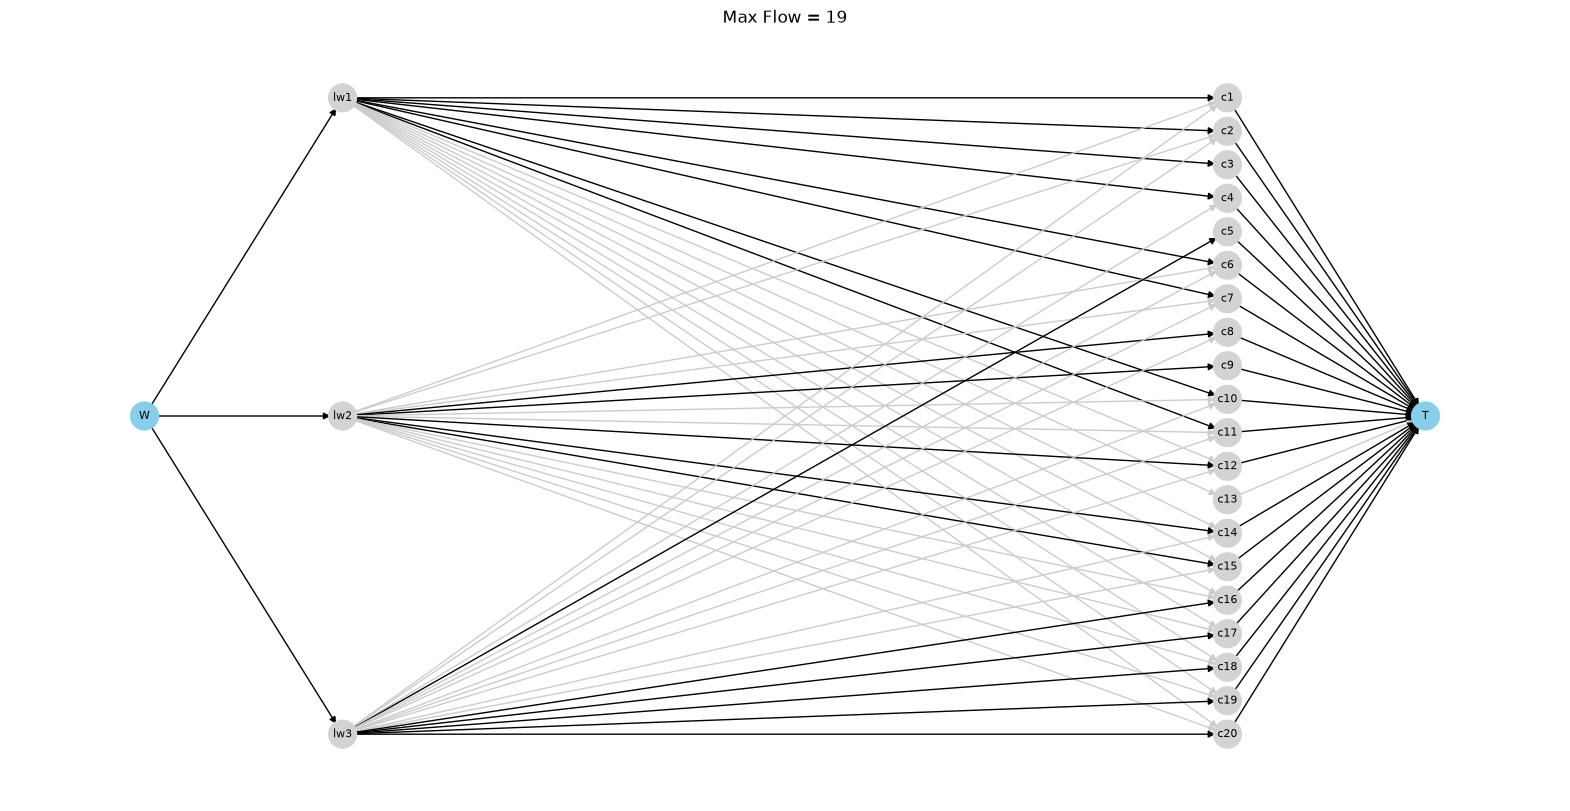

In [32]:
# assign colors and labels to nodes based on their type
node_colors = ["skyblue" if u in {"W", "T"} else "lightgray" for u in B.nodes]

# calculating the maximum flow with the cutoff value
R = nx.flow.dinitz(B, s="W", t="T", capacity="capacity")

# coloring and labeling edges depending on if they have non-zero flow value or not
edge_colors = ["0.8" if R[u][v]["flow"] == 0 else "0" for u, v in B.edges]

# drawing the network
plt.figure(figsize=(20, 10))
nx.draw_networkx_nodes(B, pos=pos, node_size=400, node_color=node_colors)
nx.draw_networkx_labels(B, pos=pos, font_size=8)
nx.draw_networkx_edges(B, pos=pos, edge_color=edge_colors)
plt.title(f"Max Flow = {R.graph['flow_value']}", size=12)
plt.axis("off")
plt.show()

Con esto tenemos un match que nos da el máximo envío en un día.